# 09d — Global Warming Potential and radiative forcing

This notebook works through the first-principles atmospheric physics
behind the GWP-100 conversion factors used everywhere else in carbon
accounting (e.g. in `09b`, which just used CO2/CH4/N2O GWP-100 values as
given inputs). No external data dependency — all self-contained
atmospheric-physics functions.

The long-horizon (5000-year) extension of the CO2/CH4 remaining-fraction
plot is folded into section 2 as a second panel rather than built as its
own section.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad

DATA_DIR = "../../data"
plt.rcParams["figure.dpi"] = 100

## 1. GWP-weighted emissions aggregation

The basic mass-based GWP calculation: total CO2-equivalent emissions
$m = q^\top \cdot \text{gwp}$, where $q$ is a vector of physical
emissions (CO2, CH4, N2O) and `gwp` is each gas's GWP-100 conversion
factor (1, 28, 265 — AR5 values). Two illustrative emissions profiles
`A` and `B` are compared, both in total CO2e and by gas contribution.


In [2]:
gwp = np.array([1, 28, 265])
q_A = np.array([3017, 10, 1.8])
q_B = np.array([2302, 32, 3.0])

m_A = q_A @ gwp
m_B = q_B @ gwp

totals = pd.DataFrame({"Profile": ["A", "B"], "Total CO2e": [m_A, m_B]})
print(totals.to_string(index=False))
print()

mc_A = q_A * gwp
mc_B = q_B * gwp

contrib = pd.DataFrame({
    "Profile": ["A", "B"],
    "Total CO2e": [m_A, m_B],
    "CO2 contribution": [mc_A[0], mc_B[0]],
    "CH4 contribution (CO2e)": [mc_A[1], mc_B[1]],
    "N2O contribution (CO2e)": [mc_A[2], mc_B[2]],
    "CO2 share (%)": [100 * mc_A[0] / m_A, 100 * mc_B[0] / m_B],
    "CH4 share (%)": [100 * mc_A[1] / m_A, 100 * mc_B[1] / m_B],
    "N2O share (%)": [100 * mc_A[2] / m_A, 100 * mc_B[2] / m_B],
})
contrib.round(2)

Profile  Total CO2e
      A      3774.0
      B      3993.0



,Profile,Total CO2e,CO2 contribution,CH4 contribution (CO2e),N2O contribution (CO2e),CO2 share (%),CH4 share (%),N2O share (%)
0,A,3774.0,3017.0,280.0,477.0,79.94,7.42,12.64
1,B,3993.0,2302.0,896.0,795.0,57.65,22.44,19.91


## 2. Atmospheric decay: remaining airborne fraction

The Bern carbon-cycle model's multi-exponential impulse response for
CO2 (a fast + two slow decaying pools plus a permanent airborne
fraction), against methane's single-exponential ~12.4-year e-folding
decay. Left panel: a 100-year window. Right panel: the same two curves
extended to 5000 years, showing CO2's long tail (dominated by its
~394-year slow pool plus the permanent 0.2173 fraction) versus
methane's near-complete decay within a few centuries.


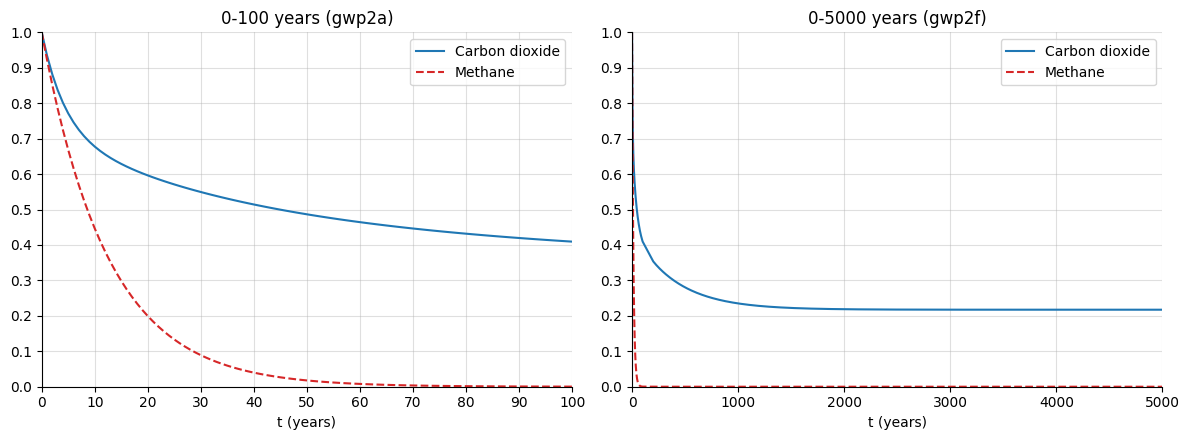

In [3]:
def decay_CO2(t):
    return (0.2173 + 0.2240 * np.exp(-t / 394.4)
            + 0.2824 * np.exp(-t / 36.54) + 0.2763 * np.exp(-t / 4.304))

def decay_CH4(t):
    return np.exp(-t / 12.4)

t_short = np.arange(0, 101, 1.0)
t_long = np.concatenate([np.arange(0, 101, 1.0), np.arange(200, 5011, 10.0)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(t_short, decay_CO2(t_short), "-", color="tab:blue", linewidth=1.5, label="Carbon dioxide")
ax.plot(t_short, decay_CH4(t_short), "--", color="tab:red", linewidth=1.5, label="Methane")
ax.set_xlim(0, 100); ax.set_xticks(range(0, 101, 10))
ax.set_ylim(0, 1); ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_xlabel("t (years)"); ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10); ax.set_title("0-100 years (gwp2a)")

ax = axes[1]
ax.plot(t_long, decay_CO2(t_long), "-", color="tab:blue", linewidth=1.5, label="Carbon dioxide")
ax.plot(t_long, decay_CH4(t_long), "--", color="tab:red", linewidth=1.5, label="Methane")
ax.set_xlim(0, 5000); ax.set_xticks(range(0, 5001, 1000))
ax.set_ylim(0, 1); ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_xlabel("t (years)"); ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10); ax.set_title("0-5000 years (gwp2f)")

plt.tight_layout()
plt.show()

## 3. Decay-rate densities

The (negative) time-derivative of each decay function — the pulse
"density" at which each pool's remaining fraction declines. For CO2
this is a weighted sum of three exponential rates $1/\tau_i$
(reported below in per-mille units); for methane it's the single rate
$1/12.4\,\text{yr}^{-1}$.


1e3 x lambda_CO2 (per-mille/year): [  0.      2.535  27.367 232.342]


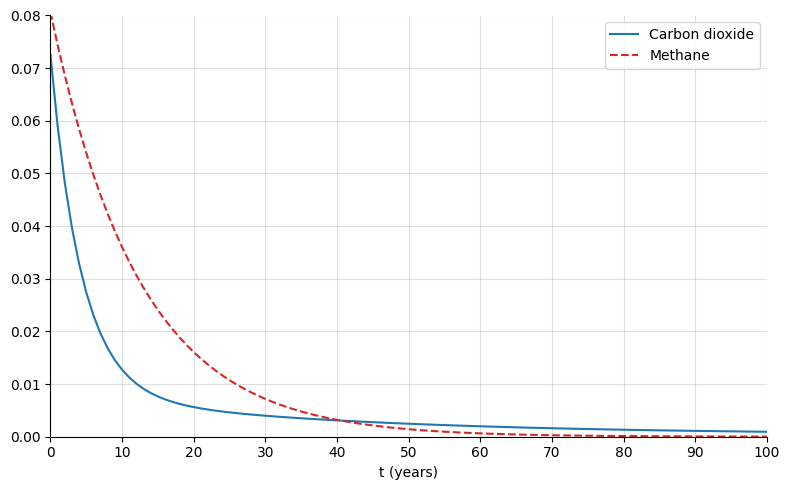

In [4]:
mean_CO2 = np.array([np.inf, 394.4, 36.54, 4.304])
lambda_CO2 = 1 / mean_CO2
print("1e3 x lambda_CO2 (per-mille/year):", np.round(1e3 * lambda_CO2, 3))

def density_CO2(t):
    return (0.2240 / 394.4 * np.exp(-t / 394.4)
            + 0.2824 / 36.54 * np.exp(-t / 36.54)
            + 0.2763 / 4.304 * np.exp(-t / 4.304))

def density_CH4(t):
    return 1 / 12.4 * np.exp(-t / 12.4)

t = np.arange(0, 101, 1.0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, density_CO2(t), "-", color="tab:blue", linewidth=1.5, label="Carbon dioxide")
ax.plot(t, density_CH4(t), "--", color="tab:red", linewidth=1.5, label="Methane")
ax.set_xlim(0, 100); ax.set_xticks(range(0, 101, 10))
ax.set_ylim(0, 0.08); ax.set_yticks(np.arange(0, 0.081, 0.01))
ax.set_xlabel("t (years)"); ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 4. Absolute Global Warming Potential — AGWP(t)

$\mathrm{AGWP}(t) = \int_0^t A \cdot \text{decay}(s)\,ds$, the
cumulative radiative forcing from a unit pulse emission, where $A$ is
each gas's radiative efficiency (W/m^2 per ppb, AR5 values). CO2 and
methane are shown on separate panels since their radiative efficiencies
differ by two orders of magnitude (note the different y-axis scaling
factors).


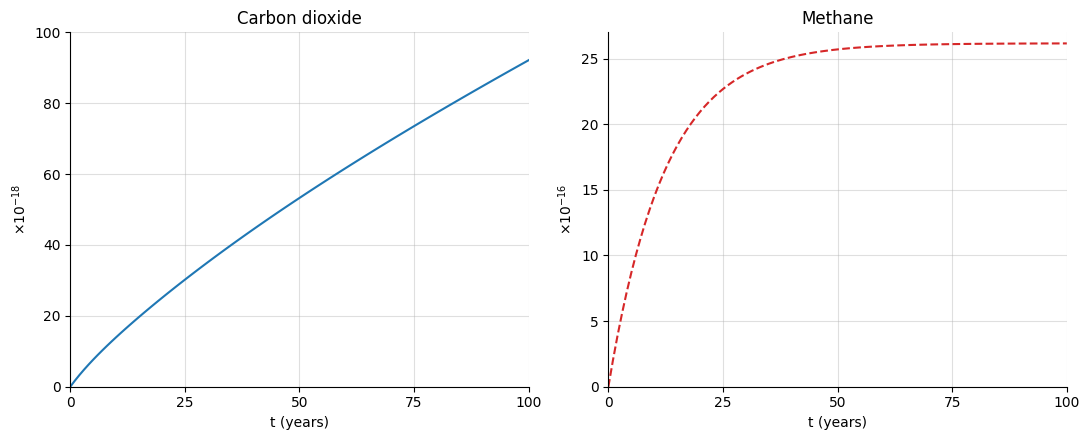

In [5]:
A_CO2, A_CH4 = 1.76, 2.11

def RF_CO2(t): return A_CO2 * decay_CO2(t)
def RF_CH4(t): return A_CH4 * decay_CH4(t)

def AGWP_CO2(t): return quad(RF_CO2, 0, t)[0] if t > 0 else 0.0
def AGWP_CH4(t): return quad(RF_CH4, 0, t)[0] if t > 0 else 0.0

t = np.arange(0, 101, 1.0)
y1 = np.array([AGWP_CO2(ti) for ti in t])
y2 = np.array([AGWP_CH4(ti) for ti in t])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.plot(t, y1, "-", color="tab:blue", linewidth=1.5)
ax.set_title("Carbon dioxide"); ax.set_xlabel("t (years)"); ax.set_ylabel(r"$\times 10^{-18}$")
ax.set_xlim(0, 100); ax.set_xticks(range(0, 101, 25))
ax.set_ylim(0, 100); ax.set_yticks(range(0, 101, 20))
ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.plot(t, y2, "--", color="tab:red", linewidth=1.5)
ax.set_title("Methane"); ax.set_xlabel("t (years)"); ax.set_ylabel(r"$\times 10^{-16}$")
ax.set_xlim(0, 100); ax.set_xticks(range(0, 101, 25))
ax.set_ylim(0, 27); ax.set_yticks(range(0, 26, 5))
ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 5. GWP(t) and the GWP-100 convention

$\mathrm{gwp}_{\mathrm{CH}_4}(t) = \mathrm{AGWP}_{\mathrm{CH}_4}(t)
/ \mathrm{AGWP}_{\mathrm{CO}_2}(t)$ — methane's time-horizon-dependent
global warming potential relative to CO2. It starts far above 28
(methane's radiative efficiency is much higher per-molecule and its
early decay is still slow relative to CO2's fast initial pools) and
falls as the horizon lengthens and CO2's long tail keeps accumulating
forcing while methane's has mostly decayed away. The commonly quoted
GWP-100 value is exactly where this curve is evaluated at $t=100$.


GWP_CH4(100) = 28.39


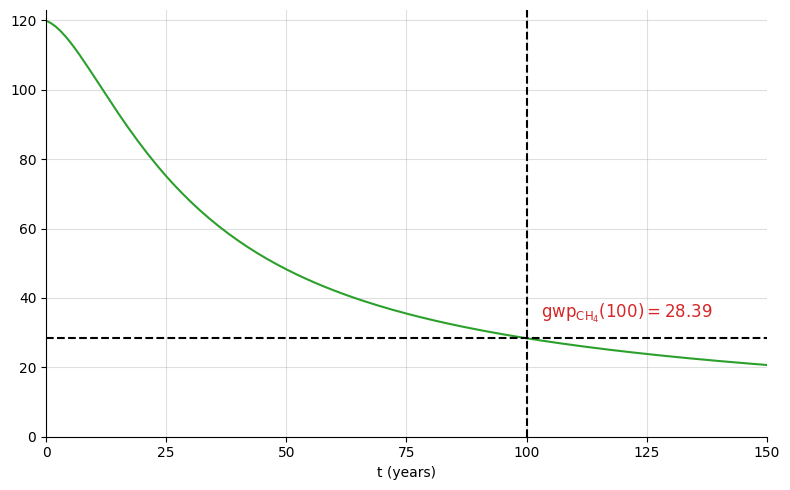

In [6]:
t = np.concatenate([np.arange(0, 1.01, 0.1), np.arange(1, 151, 1.0)])
y1 = np.array([AGWP_CO2(ti) for ti in t])
y2 = np.array([AGWP_CH4(ti) for ti in t])

with np.errstate(divide="ignore", invalid="ignore"):
    gwp_t = (1e-16 * y2) / (1e-18 * y1)
gwp_100 = 100 * AGWP_CH4(100) / AGWP_CO2(100)
print(f"GWP_CH4(100) = {gwp_100:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
mask = t > 0
ax.plot(t[mask], gwp_t[mask], "-", color="tab:green", linewidth=1.5)
ax.axhline(gwp_100, linestyle="--", color="black", linewidth=1.5)
ax.axvline(100, linestyle="--", color="black", linewidth=1.5)
ax.annotate(rf"$\mathrm{{gwp}}_{{\mathrm{{CH}}_4}}(100) = {gwp_100:.2f}$",
            xy=(103, gwp_100 + 6), fontsize=12, color="tab:red")
ax.set_xlim(0, 150); ax.set_xticks(range(0, 151, 25))
ax.set_ylim(0, 123); ax.set_yticks(range(0, 121, 20))
ax.set_xlabel("t (years)"); ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Long-horizon limit

A single-value worked example evaluating $\mathrm{gwp}_{\mathrm{CH}_4}(t)$
at a very long horizon ($t=6382$ years), illustrating that methane's
relative GWP keeps falling well below its GWP-100 value once CO2's slow
pools have had thousands of years to accumulate forcing.


In [7]:
t_far = 6382
ratio = 100 * AGWP_CH4(t_far) / AGWP_CO2(t_far)
print(f"gwp_CH4({t_far}) = {ratio:.4f}")

gwp_CH4(6382) = 1.0000
